# Day 10: PINN Training

Combines the Day 6 weighted data loss with the Day 9 physics penalty terms into a single training loop.

**Architecture:** 201 → 256 → 128 → 64 → 100 (identical to Day 6)  
**Data loss:** weighted MSE — W_COEFF=49 for Cl/Cd, W_CP=1 for each Cp point  
**Physics loss:** `PhysicsLoss` from `physics_loss.py` (v2 — corrected ΔCp lift integral)  
**Total loss:** `L_total = L_data + physics_losses['total']`

**Baseline to beat (Day 6 weighted MLP, val set):**

| Target | MAE    | RMSE   | R²    |
|--------|--------|--------|-------|
| Cl     | 0.0900 | 0.1276 | 0.984 |
| Cd     | 0.1745 | 0.2926 | 0.914 |
| Cp     | 0.0318 | 0.2588 | 0.839 |

**Experiments:**
- Config A (default):   λ_lift=1.0, λ_smooth=0.01, λ_drag=0.1, λ_cdp=0.1
- Config B (high lift): λ_lift=5.0, λ_smooth=0.01, λ_drag=0.1, λ_cdp=0.1
- Config C (high smooth): λ_lift=1.0, λ_smooth=0.1,  λ_drag=0.1, λ_cdp=0.1
- Config D (near-baseline): λ_lift=0.01, λ_smooth=0.01, λ_drag=0.01, λ_cdp=0.01

> **Note:** This is a physics-constrained surrogate model, not a classical PINN.
> No PDE residuals are computed. The NASA dataset lacks interior velocity/pressure
> fields required for Navier-Stokes enforcement. Physics constraints are derived
> from aerodynamic theory (lift-pressure consistency, smoothness, drag bounds).
> Frame results accordingly in the paper.

In [3]:
# ── Setup ─────────────────────────────────────────────────────────────────
# Run this if starting fresh on Colab (skip if dataset already downloaded)

!wget https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
!unzip -q dataset-processed.zip
!python preprocess_airfoil_dataset.py \
    --input_dir datasets/standard \
    --output_dir processed_output \
    --scaler_name standard

# Upload physics_loss.py (v2) to Colab before running, or place it in the
# same directory as this notebook.

--2026-07-01 02:01:18--  https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
Resolving nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)... 52.216.37.177, 16.15.254.22, 16.15.223.26, ...
Connecting to nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)|52.216.37.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9188863364 (8.6G) [application/zip]
Saving to: ‘dataset-processed.zip’

dataset-processed.z 100%[===================>]   8.56G  39.2MB/s    in 3m 42s  

2026-07-01 02:05:00 (39.6 MB/s) - ‘dataset-processed.zip’ saved [9188863364/9188863364]

Processing scaler variant: standard
 cp_variant=main
  Loading dnn_scaled_data_train.pt ...
  Loading dnn_scaled_data_test.pt ...
  -> wrote processed_output/standard/main (train=457283, val=80696, test=230563)
 cp_variant=cp
  Loading dnn_scaled_data_cp_train.pt ...
  Loading dnn_scaled_data_cp_test.pt ...
  -> wrote processed_output/standard/cp (

In [4]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from physics_loss import PhysicsLoss, verify_constraints

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
os.makedirs("artifacts", exist_ok=True)

Device: cuda


In [5]:
# ── Data loading ──────────────────────────────────────────────────────────
# Identical to Day 6 — same .npz files, same feature/target construction.

train = np.load("processed_output/standard/main/train.npz")
val   = np.load("processed_output/standard/main/val.npz")

def make_X(split):
    return np.hstack([
        split["geometry_y"],
        split["alpha"].reshape(-1, 1),
        split["reynolds"].reshape(-1, 1),
        split["ncrit"].reshape(-1, 1)
    ]).astype(np.float32)  # (N, 201)

def make_y_full(split):
    """Full target for PINN: [Cl, Cd, Cdp, Cm, Cp×98] = 102 cols.
    Cdp is NOT predicted but is needed for the drag_consistency physics loss.
    The model only outputs 100 values (Cl, Cd, Cp×98)."""
    return np.concatenate([
        split["cl"].reshape(-1, 1),
        split["cd"].reshape(-1, 1),
        split["cdp"].reshape(-1, 1),   # col 2 — used by drag_consistency only
        split["cm"].reshape(-1, 1),    # col 3 — carried along for completeness
        split["cp"]                    # cols 4..101
    ], axis=1).astype(np.float32)      # (N, 102)

def make_y_model(split):
    """Model target only (100 cols): [Cl, Cd, Cp×98].
    Used for the data loss — must match model output shape."""
    return np.concatenate([
        split["cl"].reshape(-1, 1),
        split["cd"].reshape(-1, 1),
        split["cp"]
    ], axis=1).astype(np.float32)      # (N, 100)

X_train = make_X(train)
X_val   = make_X(val)

# y_model: (N, 100) — for data loss and metric evaluation
y_train_model = make_y_model(train)
y_val_model   = make_y_model(val)

# y_full: (N, 102) — for physics loss (needs Cdp at col 2)
y_train_full  = make_y_full(train)
y_val_full    = make_y_full(val)

print(f"Train: X={X_train.shape}  y_model={y_train_model.shape}  y_full={y_train_full.shape}")
print(f"Val:   X={X_val.shape}    y_model={y_val_model.shape}    y_full={y_val_full.shape}")

Train: X=(457283, 201)  y_model=(457283, 100)  y_full=(457283, 102)
Val:   X=(80696, 201)    y_model=(80696, 100)    y_full=(80696, 102)


In [6]:
# ── DataLoaders ───────────────────────────────────────────────────────────
# We pass BOTH y_model (100) and y_full (102) through the loader as a tuple
# so the training loop can use the right one for each loss term.

BATCH_SIZE = 1024

def make_loaders(X, y_model, y_full, batch_size=BATCH_SIZE, shuffle=True):
    X_t      = torch.tensor(X,       dtype=torch.float32)
    ym_t     = torch.tensor(y_model, dtype=torch.float32)
    yf_t     = torch.tensor(y_full,  dtype=torch.float32)
    ds       = TensorDataset(X_t, ym_t, yf_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)

train_loader = make_loaders(X_train, y_train_model, y_train_full, shuffle=True)
val_loader   = make_loaders(X_val,   y_val_model,   y_val_full,   shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train batches: 447  |  Val batches: 79


In [7]:
# ── Model architecture ─────────────────────────────────────────────────────
# Identical to Day 6. Output is 100 = [Cl, Cd, Cp×98].

class MLP(nn.Module):
    def __init__(self, in_dim=201, out_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),    nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)

print(MLP())

MLP(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=100, bias=True)
  )
)


In [8]:
# ── Loss functions ─────────────────────────────────────────────────────────

# Data loss: weighted MSE from Day 6 (unchanged)
W_COEFF = 49.0
W_CP    = 1.0
output_weights = torch.tensor(
    [W_COEFF, W_COEFF] + [W_CP] * 98, dtype=torch.float32
).to(DEVICE)

def weighted_mse(pred, target, weights):
    """Weighted MSE — same as Day 6."""
    sq_err = (pred - target) ** 2         # (B, 100)
    w_norm = weights / weights.sum()      # normalise so scale is stable
    return (sq_err * w_norm).sum(dim=1).mean()

In [9]:
# ── Training function ──────────────────────────────────────────────────────

def train_pinn(config_name, lambda_lift, lambda_smooth, lambda_drag, lambda_cdp,
               epochs=20, lr=1e-3):
    """
    Train one PINN configuration.

    Returns:
        history (list of dicts) — one entry per epoch with all loss terms
        model  — best checkpoint (by val total loss)
    """
    print(f"\n{'='*65}")
    print(f"  Config {config_name}: λ_lift={lambda_lift}  λ_smooth={lambda_smooth}"
          f"  λ_drag={lambda_drag}  λ_cdp={lambda_cdp}")
    print(f"{'='*65}")

    model   = MLP().to(DEVICE)
    physics = PhysicsLoss(
        lambda_lift=lambda_lift,
        lambda_smooth=lambda_smooth,
        lambda_drag=lambda_drag,
        lambda_cdp=lambda_cdp
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state    = None
    history       = []

    for epoch in range(1, epochs + 1):

        # ── Train ────────────────────────────────────────────────────────
        model.train()
        totals = dict(data=0.0, lift=0.0, smooth=0.0, drag=0.0, cdp=0.0, total=0.0)
        n_batches = 0

        for x, y_model, y_full in train_loader:
            x       = x.to(DEVICE)
            y_model = y_model.to(DEVICE)
            y_full  = y_full.to(DEVICE)

            optimizer.zero_grad()
            pred = model(x)

            data_loss    = weighted_mse(pred, y_model, output_weights)
            phys_losses  = physics(pred, y_full)
            total_loss   = data_loss + phys_losses["total"]

            total_loss.backward()
            optimizer.step()

            totals["data"]   += data_loss.item()
            totals["lift"]   += phys_losses["lift"].item()
            totals["smooth"] += phys_losses["smooth"].item()
            totals["drag"]   += phys_losses["drag"].item()
            totals["cdp"]    += phys_losses["cdp"].item()
            totals["total"]  += total_loss.item()
            n_batches += 1

        train_avgs = {k: v / n_batches for k, v in totals.items()}

        # ── Validate ─────────────────────────────────────────────────────
        model.eval()
        val_totals  = dict(data=0.0, total=0.0)
        n_val_batches = 0

        with torch.no_grad():
            for x, y_model, y_full in val_loader:
                x       = x.to(DEVICE)
                y_model = y_model.to(DEVICE)
                y_full  = y_full.to(DEVICE)

                pred         = model(x)
                data_loss    = weighted_mse(pred, y_model, output_weights)
                phys_losses  = physics(pred, y_full)
                total_loss   = data_loss + phys_losses["total"]

                val_totals["data"]  += data_loss.item()
                val_totals["total"] += total_loss.item()
                n_val_batches += 1

        val_data_loss  = val_totals["data"]  / n_val_batches
        val_total_loss = val_totals["total"] / n_val_batches

        # ── Log ──────────────────────────────────────────────────────────
        print(
            f"Epoch {epoch:02d} | "
            f"data={train_avgs['data']:.4f} | "
            f"lift={train_avgs['lift']:.4f} | "
            f"smooth={train_avgs['smooth']:.4f} | "
            f"drag={train_avgs['drag']:.4f} | "
            f"cdp={train_avgs['cdp']:.4f} | "
            f"total={train_avgs['total']:.4f} || "
            f"val_data={val_data_loss:.4f}  val_total={val_total_loss:.4f}"
        )

        history.append({
            "epoch":        epoch,
            "train_data":   train_avgs["data"],
            "train_lift":   train_avgs["lift"],
            "train_smooth": train_avgs["smooth"],
            "train_drag":   train_avgs["drag"],
            "train_cdp":    train_avgs["cdp"],
            "train_total":  train_avgs["total"],
            "val_data":     val_data_loss,
            "val_total":    val_total_loss,
        })

        # Save best by val total loss
        if val_total_loss < best_val_loss:
            best_val_loss = val_total_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Load best weights back
    model.load_state_dict(best_state)
    print(f"\nBest val total loss: {best_val_loss:.6f}")
    return model, history

In [10]:
# ── Evaluation helper ──────────────────────────────────────────────────────

def evaluate_model(model, X_val, y_val_model, y_val_full, config_name):
    """
    Evaluate model on val set.
    Returns metrics dict and pred tensor.
    """
    model.eval()
    X_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        pred = model(X_t).cpu().numpy()

    pred_cl = pred[:, 0];  true_cl = y_val_model[:, 0]
    pred_cd = pred[:, 1];  true_cd = y_val_model[:, 1]
    pred_cp = pred[:, 2:]; true_cp = y_val_model[:, 2:]

    cl_mae  = mean_absolute_error(true_cl, pred_cl)
    cl_rmse = np.sqrt(mean_squared_error(true_cl, pred_cl))
    cl_r2   = r2_score(true_cl, pred_cl)

    cd_mae  = mean_absolute_error(true_cd, pred_cd)
    cd_rmse = np.sqrt(mean_squared_error(true_cd, pred_cd))
    cd_r2   = r2_score(true_cd, pred_cd)

    cp_mae  = mean_absolute_error(true_cp, pred_cp)
    cp_rmse = np.sqrt(mean_squared_error(true_cp, pred_cp))
    cp_r2   = r2_score(true_cp, pred_cp)

    print(f"\n── {config_name} Validation Metrics ──")
    print(f"  Cl | MAE={cl_mae:.4f}  RMSE={cl_rmse:.4f}  R²={cl_r2:.4f}  "
          f"(baseline: MAE=0.0900 R²=0.984)")
    print(f"  Cd | MAE={cd_mae:.4f}  RMSE={cd_rmse:.4f}  R²={cd_r2:.4f}  "
          f"(baseline: MAE=0.1745 R²=0.914)")
    print(f"  Cp | MAE={cp_mae:.4f}  RMSE={cp_rmse:.4f}  R²={cp_r2:.4f}  "
          f"(baseline: MAE=0.0318 R²=0.839)")

    # Physics constraint verification
    print()
    pred_t    = torch.tensor(pred, dtype=torch.float32)
    y_full_t  = torch.tensor(y_val_full, dtype=torch.float32)
    constraint_results = verify_constraints(pred_t, y_full_t, verbose=True)

    metrics = {
        "config":    config_name,
        "cl_mae":  float(cl_mae),  "cl_rmse":  float(cl_rmse),  "cl_r2":  float(cl_r2),
        "cd_mae":  float(cd_mae),  "cd_rmse":  float(cd_rmse),  "cd_r2":  float(cd_r2),
        "cp_mae":  float(cp_mae),  "cp_rmse":  float(cp_rmse),  "cp_r2":  float(cp_r2),
        "constraints": {
            k: float(v) if v is not None else None
            for k, v in constraint_results.items()
        }
    }
    return metrics, pred

In [14]:
# ── Pre-training baseline constraint check ─────────────────────────────────
# Verify Day 6 model's physics constraint rates BEFORE PINN training.
# This is the "before" number that Day 10 should improve on.
#
# Load Day 6 checkpoint. Adjust path if yours is named differently.

print("=" * 65)
print("PRE-TRAINING: Day 6 baseline constraint verification")
print("=" * 65)

day6_model = MLP().to(DEVICE)
day6_model.load_state_dict(
    torch.load("weighted_cl_cd_cp.pt", map_location=DEVICE)
)
day6_model.eval()

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    day6_pred = day6_model(X_val_t)

y_val_full_t = torch.tensor(y_val_full, dtype=torch.float32)
baseline_constraints = verify_constraints(day6_pred.cpu(), y_val_full_t, verbose=True)

PRE-TRAINING: Day 6 baseline constraint verification
=== Physics Constraint Verification ===
  Drag positivity  (Cd >= 0):        36.9% of predictions
  Drag consistency (Cd >= Cdp):      60.3% of predictions
  Cp smoothness    (mean sq diff):   0.611920
  Lift-Cp correlation (corrected):   0.9983

  Note: lift_cp_correlation uses ΔCp = Cp_pressure − Cp_suction
  integrated trapezoidally over x/c=[0,1] (48 interior points).
  v1 used the raw 98-pt loop integral — that metric is now removed.


In [12]:
# ── Run all 4 configurations ───────────────────────────────────────────────

EPOCHS = 20

configs = [
    # (name,             l_lift, l_smooth, l_drag, l_cdp)
    ("A_default",        1.0,    0.01,     0.1,    0.1),
    ("B_high_lift",      5.0,    0.01,     0.1,    0.1),
    ("C_high_smooth",    1.0,    0.1,      0.1,    0.1),
    ("D_near_baseline",  0.01,   0.01,     0.01,   0.01),
]

all_results   = {}
all_histories = {}

for config_name, ll, ls, ld, lc in configs:
    model, history = train_pinn(
        config_name,
        lambda_lift=ll, lambda_smooth=ls,
        lambda_drag=ld, lambda_cdp=lc,
        epochs=EPOCHS
    )
    metrics, pred = evaluate_model(
        model, X_val, y_val_model, y_val_full, config_name
    )
    all_results[config_name]   = metrics
    all_histories[config_name] = history

print("\nAll configurations done.")


  Config A_default: λ_lift=1.0  λ_smooth=0.01  λ_drag=0.1  λ_cdp=0.1
Epoch 01 | data=0.6876 | lift=0.0019 | smooth=0.0170 | drag=0.1403 | cdp=0.1968 | total=0.7234 || val_data=0.5363  val_total=0.5744
Epoch 02 | data=0.5583 | lift=0.0001 | smooth=0.0068 | drag=0.2336 | cdp=0.0919 | total=0.5910 || val_data=0.5197  val_total=0.5557
Epoch 03 | data=0.5439 | lift=0.0001 | smooth=0.0079 | drag=0.2413 | cdp=0.0782 | total=0.5760 || val_data=0.5248  val_total=0.5511
Epoch 04 | data=0.5367 | lift=0.0001 | smooth=0.0091 | drag=0.2426 | cdp=0.0727 | total=0.5684 || val_data=0.5141  val_total=0.5408
Epoch 05 | data=0.5312 | lift=0.0000 | smooth=0.0110 | drag=0.2439 | cdp=0.0670 | total=0.5625 || val_data=0.5212  val_total=0.5450
Epoch 06 | data=0.5227 | lift=0.0000 | smooth=0.0156 | drag=0.2446 | cdp=0.0650 | total=0.5539 || val_data=0.4860  val_total=0.5245
Epoch 07 | data=0.5125 | lift=0.0000 | smooth=0.0233 | drag=0.2450 | cdp=0.0639 | total=0.5436 || val_data=0.4701  val_total=0.5006
Epoch 

In [15]:
# ── Pick best config and save artifacts ────────────────────────────────────
# Best = lowest val data loss (not total loss, since physics weights differ
# across configs and make total losses incomparable between them).

best_config = min(
    all_results,
    key=lambda k: all_results[k]["cl_mae"] + all_results[k]["cd_mae"]
)
print(f"Best config by (MAE_cl + MAE_cd): {best_config}")

# Retrain best config to get the model object (or store models in a dict above)
# If you stored them above, just reuse that. Simplest: retrain once more.
best_ll, best_ls, best_ld, best_lc = {
    name: (ll, ls, ld, lc) for name, ll, ls, ld, lc in configs
}[best_config]

best_model, _ = train_pinn(
    best_config + "_FINAL",
    lambda_lift=best_ll, lambda_smooth=best_ls,
    lambda_drag=best_ld, lambda_cdp=best_lc,
    epochs=EPOCHS
)

torch.save(best_model.state_dict(), "artifacts/pinn_v1.pt")
print("Saved: artifacts/pinn_v1.pt")

# Compile all metrics into one JSON
output_json = {
    "day6_baseline": {
        "cl_mae": 0.0900, "cl_rmse": 0.1276, "cl_r2": 0.984,
        "cd_mae": 0.1745, "cd_rmse": 0.2926, "cd_r2": 0.914,
        "cp_mae": 0.0318, "cp_rmse": 0.2588, "cp_r2": 0.839,
        "baseline_constraints": {
            k: float(v) if v is not None else None
            for k, v in baseline_constraints.items()
        }
    },
    "pinn_configs":    all_results,
    "best_config":     best_config,
    "best_config_weights": {
        "lambda_lift":   best_ll,
        "lambda_smooth": best_ls,
        "lambda_drag":   best_ld,
        "lambda_cdp":    best_lc
    },
    "loss_weights": {"W_COEFF": W_COEFF, "W_CP": W_CP},
    "epochs": EPOCHS,
    "histories": all_histories
}

with open("artifacts/pinn_v1_metrics.json", "w") as f:
    json.dump(output_json, f, indent=2)
print("Saved: artifacts/pinn_v1_metrics.json")

Best config by (MAE_cl + MAE_cd): D_near_baseline

  Config D_near_baseline_FINAL: λ_lift=0.01  λ_smooth=0.01  λ_drag=0.01  λ_cdp=0.01
Epoch 01 | data=0.6178 | lift=0.0175 | smooth=0.0076 | drag=0.2631 | cdp=0.1861 | total=0.6225 || val_data=0.5221  val_total=0.5270
Epoch 02 | data=0.5425 | lift=0.0013 | smooth=0.0057 | drag=0.3375 | cdp=0.1152 | total=0.5471 || val_data=0.5038  val_total=0.5081
Epoch 03 | data=0.5304 | lift=0.0009 | smooth=0.0069 | drag=0.3439 | cdp=0.1018 | total=0.5349 || val_data=0.4970  val_total=0.5018
Epoch 04 | data=0.5261 | lift=0.0008 | smooth=0.0079 | drag=0.3455 | cdp=0.0966 | total=0.5306 || val_data=0.4934  val_total=0.4981
Epoch 05 | data=0.5191 | lift=0.0007 | smooth=0.0099 | drag=0.3483 | cdp=0.0899 | total=0.5236 || val_data=0.4889  val_total=0.4936
Epoch 06 | data=0.5143 | lift=0.0008 | smooth=0.0128 | drag=0.3489 | cdp=0.0880 | total=0.5188 || val_data=0.4865  val_total=0.4913
Epoch 07 | data=0.5061 | lift=0.0009 | smooth=0.0201 | drag=0.3489 | cdp=

In [16]:
# ── Summary table ──────────────────────────────────────────────────────────

import pandas as pd

rows = []
for cfg, m in all_results.items():
    rows.append({
        "Config":   cfg,
        "Cl MAE":  round(m["cl_mae"],  4),
        "Cl R²":   round(m["cl_r2"],   4),
        "Cd MAE":  round(m["cd_mae"],  4),
        "Cd R²":   round(m["cd_r2"],   4),
        "Cp MAE":  round(m["cp_mae"],  4),
        "Cp R²":   round(m["cp_r2"],   4),
        "Drag≥0%": round(m["constraints"]["drag_positivity_rate"]  * 100, 1),
        "Cd≥Cdp%": round(m["constraints"]["drag_consistency_rate"] * 100, 1)
                   if m["constraints"]["drag_consistency_rate"] is not None else "N/A",
        "Lift corr": round(m["constraints"]["lift_cp_correlation"], 4),
    })

# Add Day 6 baseline row
rows.insert(0, {
    "Config":   "Day6_baseline",
    "Cl MAE":   0.0900, "Cl R²":  0.984,
    "Cd MAE":   0.1745, "Cd R²":  0.914,
    "Cp MAE":   0.0318, "Cp R²":  0.839,
    "Drag≥0%":  round(baseline_constraints["drag_positivity_rate"]  * 100, 1),
    "Cd≥Cdp%":  round(baseline_constraints["drag_consistency_rate"] * 100, 1)
                if baseline_constraints["drag_consistency_rate"] is not None else "N/A",
    "Lift corr": round(baseline_constraints["lift_cp_correlation"], 4),
})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

         Config  Cl MAE  Cl R²  Cd MAE  Cd R²  Cp MAE  Cp R²  Drag≥0%  Cd≥Cdp%  Lift corr
  Day6_baseline  0.0900 0.9840  0.1745 0.9140  0.0318 0.8390     36.9     60.3     0.9983
      A_default  0.1019 0.9798  0.2833 0.8747  0.0403 0.7541     41.4     84.9     1.0000
    B_high_lift  0.0971 0.9814  0.2702 0.8793  0.0417 0.7099     41.4     84.4     0.9999
  C_high_smooth  0.0938 0.9825  0.2568 0.8822  0.0383 0.7298     40.2     84.9     0.9999
D_near_baseline  0.0950 0.9819  0.1752 0.9140  0.0349 0.8347     36.2     63.2     0.9996


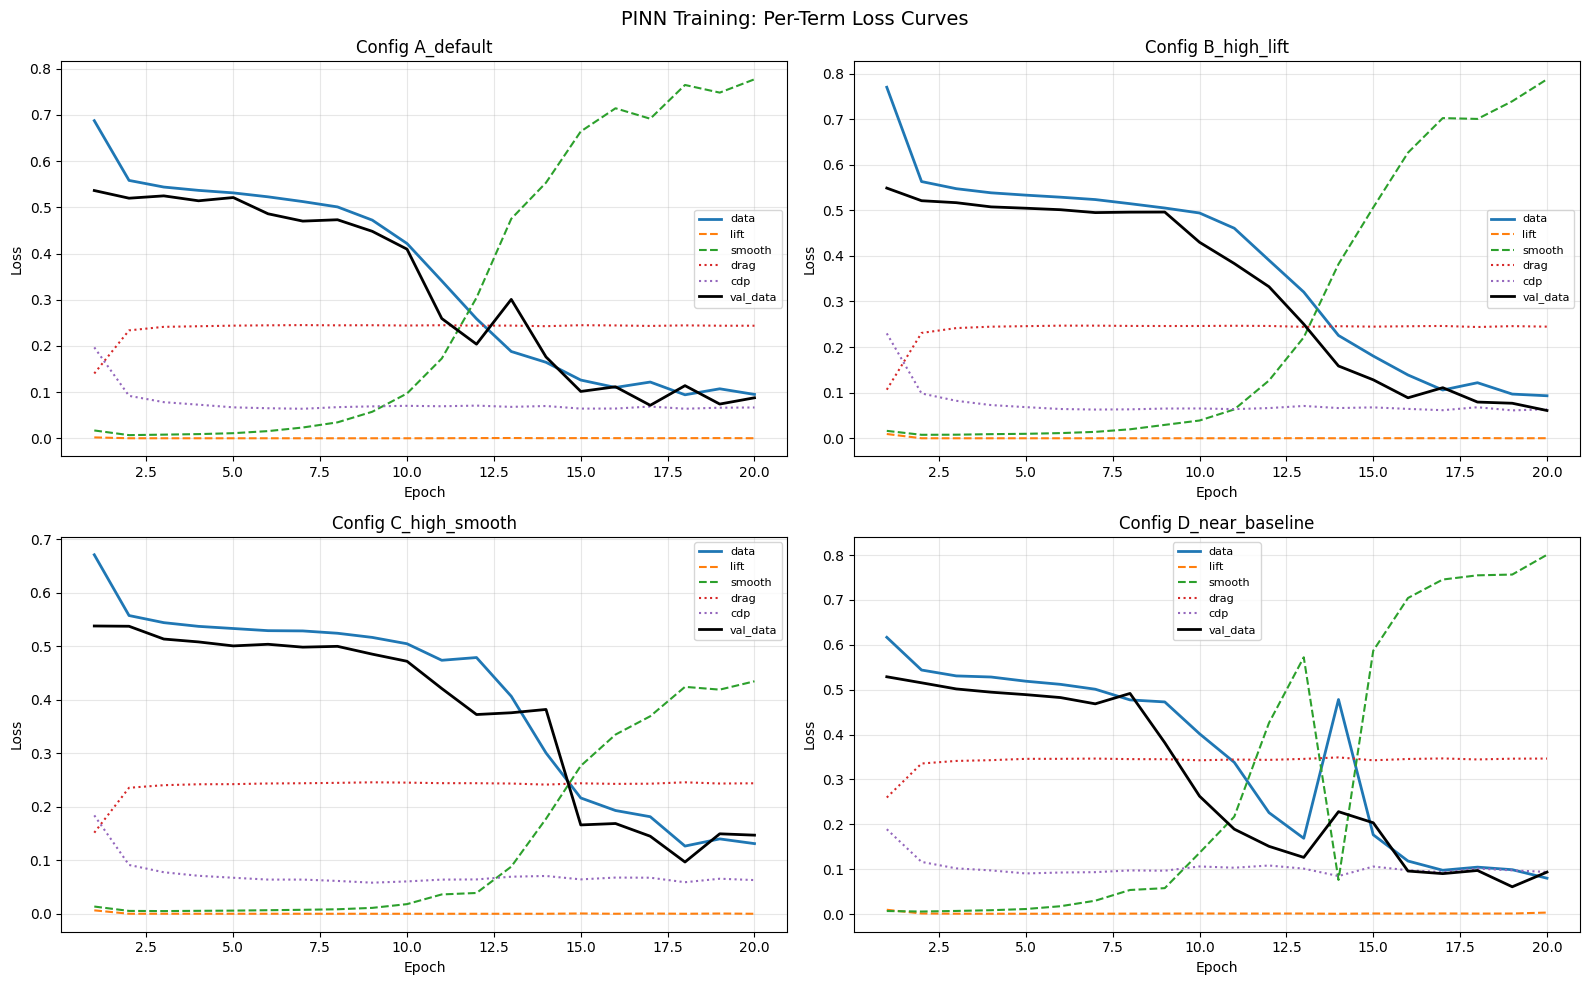

Saved: artifacts/pinn_loss_curves.png


In [17]:
# ── Loss curves ────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (cfg, history) in zip(axes, all_histories.items()):
    epochs_x = [h["epoch"] for h in history]

    ax.plot(epochs_x, [h["train_data"]   for h in history], label="data",   linewidth=2)
    ax.plot(epochs_x, [h["train_lift"]   for h in history], label="lift",   linewidth=1.5, linestyle="--")
    ax.plot(epochs_x, [h["train_smooth"] for h in history], label="smooth", linewidth=1.5, linestyle="--")
    ax.plot(epochs_x, [h["train_drag"]   for h in history], label="drag",   linewidth=1.5, linestyle=":")
    ax.plot(epochs_x, [h["train_cdp"]    for h in history], label="cdp",    linewidth=1.5, linestyle=":")
    ax.plot(epochs_x, [h["val_data"]     for h in history], label="val_data", linewidth=2,
            color="black", linestyle="-")

    ax.set_title(f"Config {cfg}", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("PINN Training: Per-Term Loss Curves", fontsize=14)
plt.tight_layout()
plt.savefig("artifacts/pinn_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/pinn_loss_curves.png")

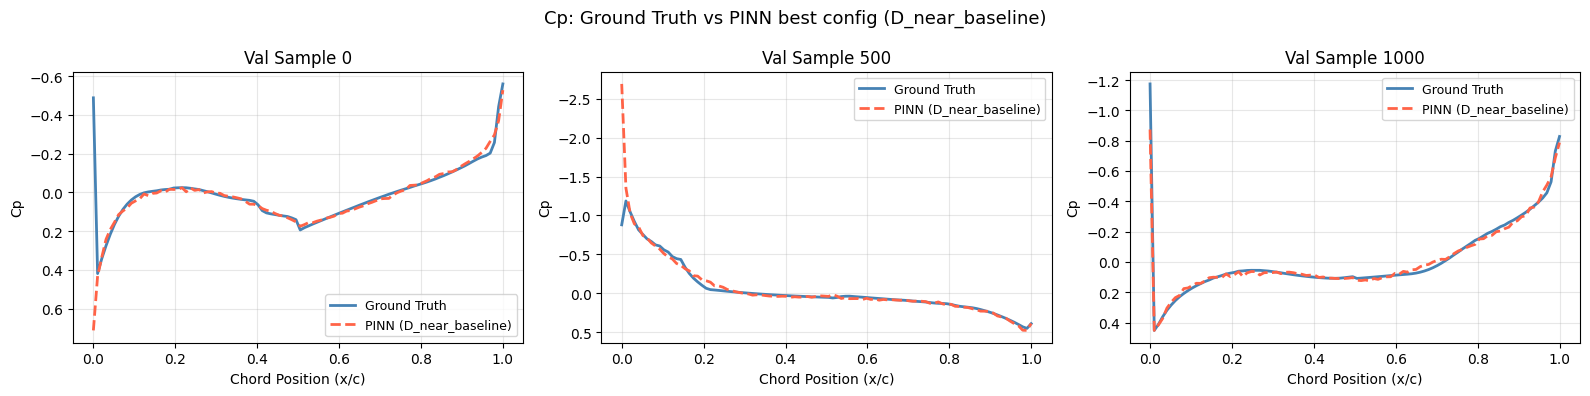

Saved: artifacts/pinn_cp_comparison.png


In [18]:
# ── Cp visual comparison ───────────────────────────────────────────────────
# Compare Day 6 baseline vs best PINN config on the same 3 val samples

best_model.eval()
with torch.no_grad():
    pinn_pred = best_model(
        torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

sample_indices = [0, 500, 1000]
x_surface      = np.linspace(0, 1, 98)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    ax.plot(x_surface, y_val_model[idx, 2:], label="Ground Truth",
            color="steelblue", linewidth=2)
    ax.plot(x_surface, pinn_pred[idx, 2:], label=f"PINN ({best_config})",
            color="tomato", linewidth=2, linestyle="--")
    ax.invert_yaxis()
    ax.set_xlabel("Chord Position (x/c)")
    ax.set_ylabel("Cp")
    ax.set_title(f"Val Sample {idx}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Cp: Ground Truth vs PINN best config ({best_config})", fontsize=13)
plt.tight_layout()
plt.savefig("artifacts/pinn_cp_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/pinn_cp_comparison.png")

In [19]:
print("\n" + "="*65)
print("Day 10 complete.")
print("="*65)
print("Artifacts saved:")
print("  artifacts/pinn_v1.pt")
print("  artifacts/pinn_v1_metrics.json")
print("  artifacts/pinn_loss_curves.png")
print("  artifacts/pinn_cp_comparison.png")
print()
print("Next steps:")
print("  Day 11 — Tune lambda weights based on per-term loss behaviour")
print("           observed above (which term dominates? which is near zero?)")
print("  Day 12 — Full PINN evaluation: compare all metrics and constraint")
print("           rates against Day 6 baseline.")


Day 10 complete.
Artifacts saved:
  artifacts/pinn_v1.pt
  artifacts/pinn_v1_metrics.json
  artifacts/pinn_loss_curves.png
  artifacts/pinn_cp_comparison.png

Next steps:
  Day 11 — Tune lambda weights based on per-term loss behaviour
           observed above (which term dominates? which is near zero?)
  Day 12 — Full PINN evaluation: compare all metrics and constraint
           rates against Day 6 baseline.
